# Mean Exit Times

In [16]:
import numpy as np

mu = 0.1
sigma = 0.2

a = 0.5
b = 2.

X0 = 1.

dt = 2e-3

M = 10**5

Te = np.zeros(M)

for s in range(M):
    X = X0

    t = 0.

    while X > a and X < b:
        dW = np.sqrt(dt) * np.random.randn()
        X = X * np.exp((mu - 0.5*sigma**2)*dt + sigma*dW)
        t += dt

    Te[s] = t - 0.5*dt

Tm = np.mean(Te)
Ts = np.std(Te)

Tl = Tm - 1.96*Ts/np.sqrt(M)
Tr = Tm + 1.96*Ts/np.sqrt(M)

print(f'Mean exit time: {Tm}')
print(f'with 95% confidence interval [{Tl}, {Tr}]')

Mean exit time: 7.715567119999882
with 95% confidence interval [7.680808824453068, 7.750325415546696]


In [17]:
T1 = 1/(0.5*sigma**2 - mu)
T2 = np.log(X0/a)

p = 1 - 2*mu/sigma**2

T3 = 1 - (X0/a)**p
T4 = 1 - (b/a)**p

T5 = np.log(b/a)

Texact = T1*(T2 - (T3/T4)*T5)

print(f'Exact mean exit time: {Texact}')

Exact mean exit time: 7.6450056679405725


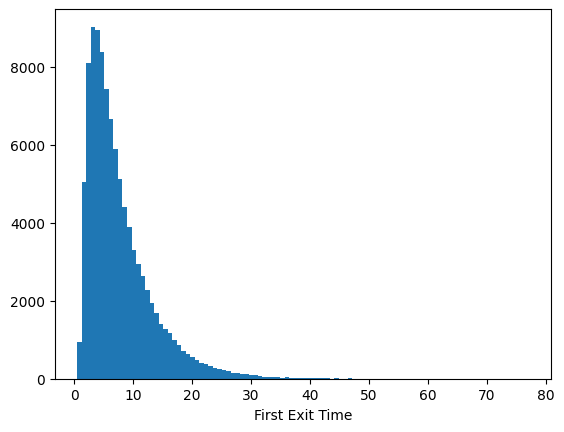

In [18]:
from matplotlib import pyplot as plt

plt.hist(Te, bins=100)
plt.xlabel('First Exit Time')
plt.show()